<a href="https://colab.research.google.com/github/suprabhak2006-dot/Codsoft/blob/main/logisticreg2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

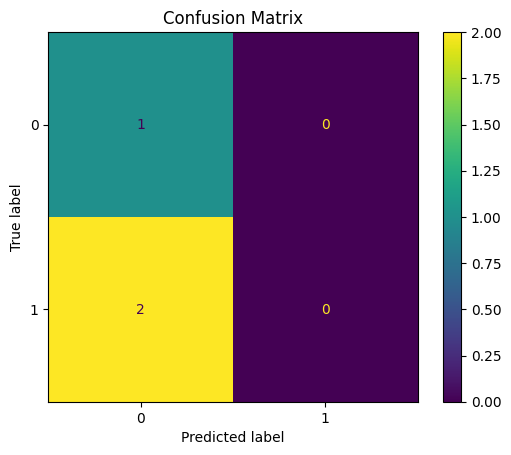

Accuracy: 0.3333333333333333


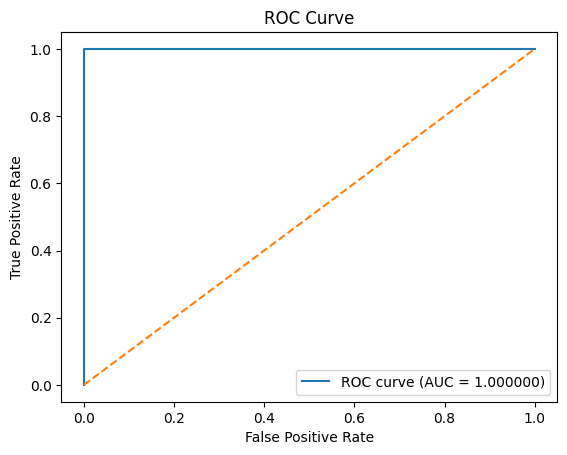

probability of passing with 33 hours study: 0.43609566998950344


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, ConfusionMatrixDisplay
X=np.array([29,15,33,28,39,10,20,45,50,5]).reshape(-1,1)
y=np.array([0,1,0,1,1,0,1,0,1,0])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
y_prob=model.predict_proba(X_test)
m=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=m)
disp.plot()
plt.title('Confusion Matrix')
plt.show()
print("Accuracy:",accuracy_score(y_test,y_pred))
fpr,tpr,thresholds=roc_curve(y_test,y_prob[:, 1])
roc_auc=auc(fpr,tpr)
plt.plot(fpr,tpr,label='ROC curve (AUC = %2f)' % roc_auc)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curve")
plt.legend()
plt.show()
prob_33=model.predict_proba([[33]])[0][1]
print("probability of passing with 33 hours study:",prob_33)
for hours in range(0,61):
  prob=model.predict_proba([[hours]])[0][1]
  if prob>0.95:
    print("Minimum hours required for >95% pass probability:",hours)
    print("probability at this hour:",prob)
    break